# Data engineering

In [38]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [39]:
#Loading data
df=pd.read_csv("../data/raw/house_data.csv")
print(f"Shape: {df.shape}")
print(f"head : \n {df.head()}")

Shape: (87, 7)
head : 
        price  sqft  bedrooms  bathrooms    location  year_built  condition
0   495000.0  1527         2        1.5      Suburb        1956       Good
1   752000.0  2526         3        2.5    Downtown        1998  Excellent
2   319000.0  1622         2        1.5       Rural        1975       Fair
3  1210000.0  3102         4        3.0  Waterfront        2005  Excellent
4   462000.0  1835         2        2.0       Urban        1982       Good


In [40]:
#Analizing
print(f"Types and null values \n")
print(df.info())
print(f"Null values \n {df.isnull().sum()}")
print(f"Describe data: \n {df.describe()}")

Types and null values 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       86 non-null     float64
 1   sqft        87 non-null     int64  
 2   bedrooms    87 non-null     int64  
 3   bathrooms   86 non-null     float64
 4   location    85 non-null     object 
 5   year_built  87 non-null     int64  
 6   condition   87 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 4.9+ KB
None
Null values 
 price         1
sqft          0
bedrooms      0
bathrooms     1
location      2
year_built    0
condition     0
dtype: int64
Describe data: 
               price         sqft   bedrooms  bathrooms   year_built
count  8.600000e+01    87.000000  87.000000  86.000000    87.000000
mean   6.321047e+05  2207.655172   2.873563   2.220930  1982.379310
std    3.611596e+05   658.272207   0.860024   0.842282    19.608518
min    2.4

In [63]:
# Processing missing values
# For target variable (Drop)
missing_target_values=df["price"].isnull().sum()
if missing_target_values>0:
    print(f"Found {missing_target_values}")
    df=df.dropna(subset=["price"])
    print(f"{missing_target_values} rows dropped")

# For features
for column in df.columns:
    missing_count=df[column].isnull().sum()
    if missing_count>0:
        print(f"Found {missing_count} missing values in {column}")
        #For numerical values
        if pd.api.types.is_numeric_dtype(df[column]):
            median_value=df[column].median()
            print(f"MEDIAN: {median_value}")
            df[column]=df[column].fillna(median_value)
            print(f"{missing_count} imputed in numerical column {column} with median")
        #For categorical values
        else:
            mode_value=df[column].mode()[0]
            print(F"MODE: {mode_value}")
            df[column]=df[column].fillna(mode_value)
            print(f"{missing_count} categorical values imputed in {column} with mode")

#Handling outliers in target values (Price) with IQR
Q1=df["price"].quantile(0.25)
Q3=df["price"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

count_outliers=((df["price"]>upper_bound) | (df["price"]<lower_bound)).sum()
if count_outliers>0:
    df=df[(df["price"]<=upper_bound) & (df["price"]>=lower_bound)]
    print(f"New shape: {df.shape}")

New shape: (70, 7)


In [43]:
print(f"Types and null values \n")
print(df.info())
print(f"Null values \n {df.isnull().sum()}")
print(f"Describe data: \n {df.describe()}")

Types and null values 

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 86
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       86 non-null     float64
 1   sqft        86 non-null     int64  
 2   bedrooms    86 non-null     int64  
 3   bathrooms   86 non-null     float64
 4   location    86 non-null     object 
 5   year_built  86 non-null     int64  
 6   condition   86 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 5.4+ KB
None
Null values 
 price         0
sqft          0
bedrooms      0
bathrooms     0
location      0
year_built    0
condition     0
dtype: int64
Describe data: 
               price         sqft   bedrooms  bathrooms   year_built
count  8.600000e+01    86.000000  86.000000  86.000000    86.000000
mean   6.321047e+05  2196.465116   2.860465   2.203488  1982.104651
std    3.611596e+05   653.756938   0.856296   0.830938    19.554466
min    2.490000

In [44]:
#Standarize column names
print(f"Before : \n{df.columns}")
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")
print(f"After : \n{df.columns}")

Before : 
Index(['price', 'sqft', 'bedrooms', 'bathrooms', 'location', 'year_built',
       'condition'],
      dtype='object')
After : 
Index(['price', 'sqft', 'bedrooms', 'bathrooms', 'location', 'year_built',
       'condition'],
      dtype='object')


In [45]:
#Outliers
print(df.describe())

              price         sqft   bedrooms  bathrooms   year_built
count  8.600000e+01    86.000000  86.000000  86.000000    86.000000
mean   6.321047e+05  2196.465116   2.860465   2.203488  1982.104651
std    3.611596e+05   653.756938   0.856296   0.830938    19.554466
min    2.490000e+05  1350.000000   2.000000   1.000000  1947.000000
25%    3.727500e+05  1685.000000   2.000000   1.500000  1965.000000
50%    5.110000e+05  1995.000000   3.000000   2.000000  1982.500000
75%    7.297500e+05  2610.000000   3.000000   2.500000  1996.500000
max    1.680000e+06  3850.000000   5.000000   4.500000  2019.000000


Index(['price', 'sqft', 'bedrooms', 'bathrooms', 'year_built'], dtype='object')
[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]


<function matplotlib.pyplot.show(close=None, block=None)>

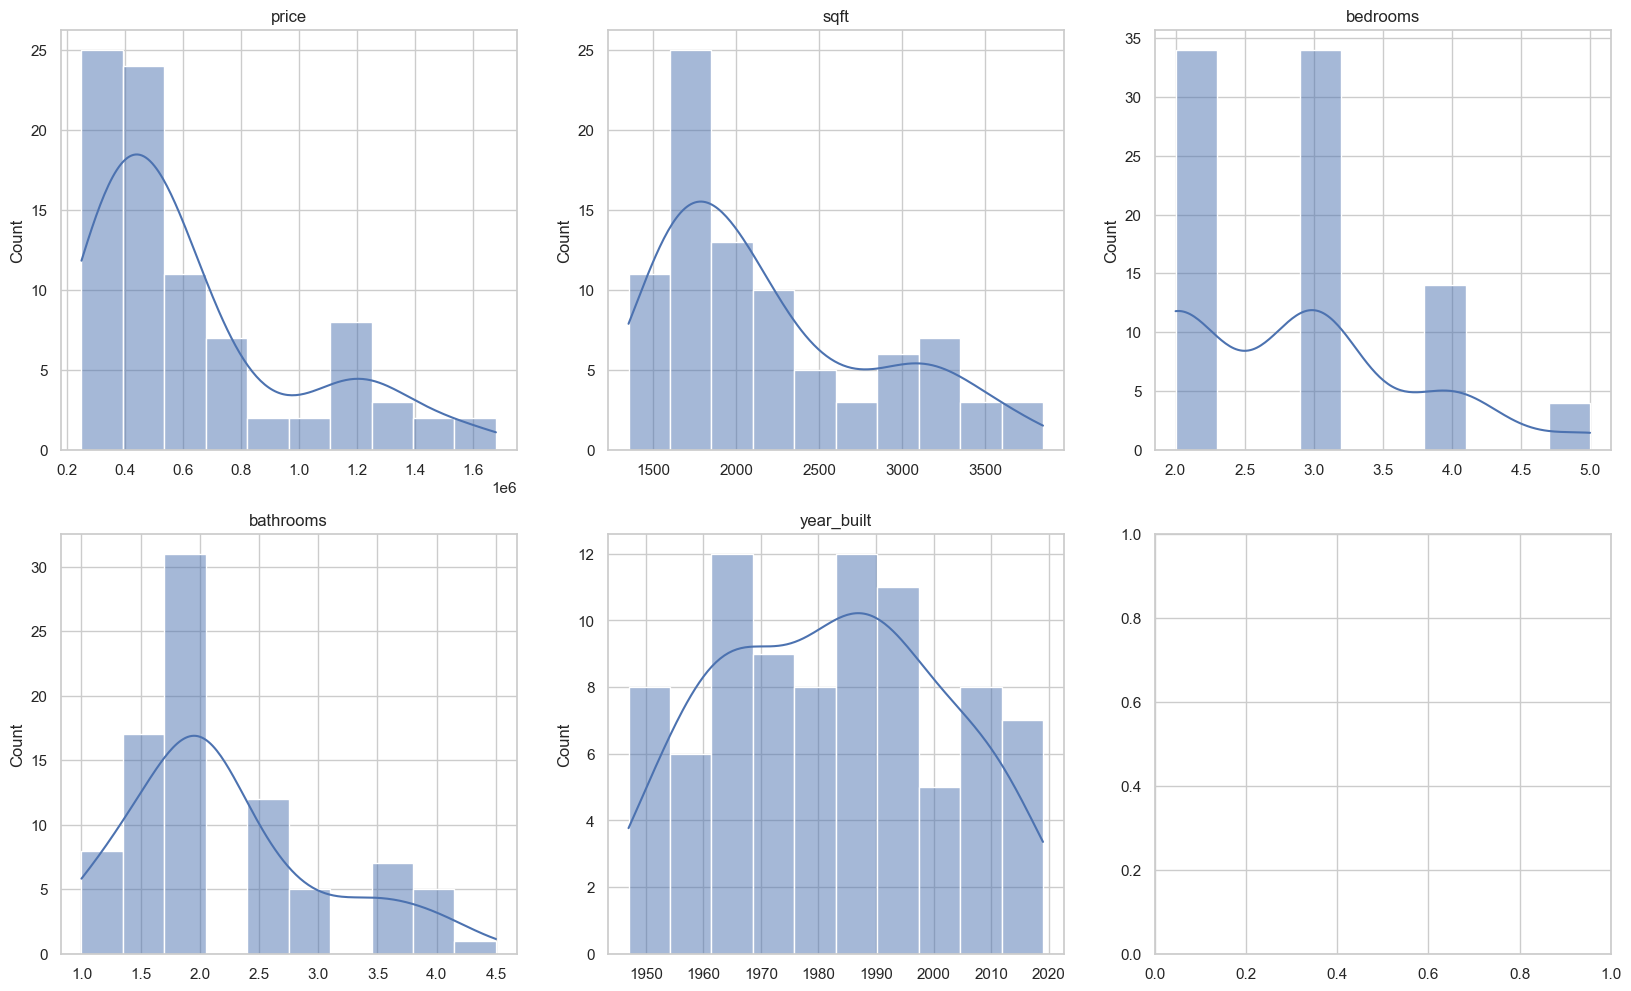

In [46]:
#Plotting distributions for numerical columns
numerical_cols=df.select_dtypes(include='number').columns
print(numerical_cols)

fig,axes=plt.subplots(ncols=3,nrows=2,figsize=(20,12))
axes_flat=axes.flatten()
print(axes.flatten())

for i,col in enumerate(numerical_cols):
    sns.histplot(data=df[col],kde=True,bins=10,ax=axes_flat[i])
    axes_flat[i].set_title(col)
    axes_flat[i].set_xlabel("")

plt.show
# plt.figure(figsize=(8,5))
# sns.histplot(df["sqft"],kde=True,bins=10)
# plt.title("Prices distribution")
# plt.show

In [47]:
#Checking negative values
for col in numerical_cols:
    is_negative_value=df[col]<0
    negative_values=df[is_negative_value]
    if negative_values.empty:
        print("No negative values")
    else:
        print(f"Negative values in {col} : \n {negative_values}")

No negative values
No negative values
No negative values
No negative values
No negative values


In [48]:
#Duplicate rows
duplicates=df.duplicated().sum()
if duplicates>0:
    print(f"{duplicates}  duplicates values found")
    df=df.drop_duplicates()
else:
    print("No duplicate rows found")

No duplicate rows found


In [49]:
#Save cleaned data

df.to_csv("../data/processed/cleaned_house_data_ds.csv",index=False)
print("Data cleaned saved")

Data cleaned saved
